# Imports

In [1]:
import ee
import numpy as np
import math
import geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
#ee.Authenticate()


In [3]:

# Initialize Google Earth Engine
ee.Initialize()

In [4]:
# Load study area and community boundaries
nm_path = r"C:\Users\bsf31\Documents\data\NM\nm_vector.gpkg"
study_boundary = gpd.read_file(nm_path, layer='counties_dissolved')

bayard_gdf = gpd.read_file(nm_path, layer='bayard')


In [5]:

ee_bayard = geemap.geopandas_to_ee(bayard_gdf).geometry()


# Landsat Collection 2

In [6]:
# Function to scale the surface temperature band and convert to Fahrenheit
def scale_lst(image):
    lst_k = image.select('ST_B10').multiply(0.00341802).add(149.0)
    lst_f = lst_k.subtract(273.15).multiply(1.8).add(32)
    return image.addBands(lst_f.rename('LST_F'))

# Function to calculate NDVI
def calculate_ndvi(image):
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4'])
    return image.addBands(ndvi.rename('NDVI'))

# Function to calculate Fraction of Vegetation Cover
def calculate_fvc(image):
    fvc = image.select('NDVI').subtract(0.2).divide(0.3).pow(2).clamp(0, 1)
    return image.addBands(fvc.rename('FVC'))

# Function to calculate Emissivity
def calculate_emissivity(image):
    emissivity = image.select('FVC').multiply(0.0004).add(0.986)
    return image.addBands(emissivity.rename('Emissivity'))

# Define a function to clip each image to the ROI
def clip_to_region(image,roi):
    return image.clip(roi)




In [7]:
""" 
# Load the Landsat 8 collection and filter images based on criteria
landsat_collection1 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate('2019-04-01', '2024-11-01') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_bayard)\
    .filter(ee.Filter.lt('CLOUD_COVER', 9))  # Filter for images with less than 10% cloud cover 

 """

' \n# Load the Landsat 8 collection and filter images based on criteria\nlandsat_collection1 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")     .filterDate(\'2019-04-01\', \'2024-11-01\')     .filter(ee.Filter.calendarRange(5, 9, \'month\'))     .filterBounds(ee_bayard)    .filter(ee.Filter.lt(\'CLOUD_COVER\', 9))  # Filter for images with less than 10% cloud cover \n\n '

In [8]:


# Load the Landsat 8 collection and filter images based on criteria
landsat_collection1 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate('2019-04-01', '2019-09-18') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_bayard)\
    .filter(ee.Filter.lt('CLOUD_COVER', 9))  # Filter for images with less than 10% cloud cover
# Load the Landsat 8 collection and filter images based on criteria
landsat_collection2 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate('2019-09-19', '2024-08-14') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_bayard)\
    .filter(ee.Filter.lt('CLOUD_COVER', 9))  # Filter for images with less than 10% cloud cover

# Load the Landsat 8 collection and filter images based on criteria
landsat_collection3 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2") \
    .filterDate( '2024-08-15', '2024-11-01') \
    .filter(ee.Filter.calendarRange(5, 9, 'month')) \
    .filterBounds(ee_bayard)\
    .filter(ee.Filter.lt('CLOUD_COVER', 9))  # Filter for images with less than 10% cloud cover 

# Combine the collections
combined_collection = landsat_collection1.merge(landsat_collection2).merge(landsat_collection3)
# Get the list of image dates that meet the criteria
image_dates = combined_collection.aggregate_array('system:time_start').map(lambda t: ee.Date(t).format('YYYY-MM-dd')).getInfo()

print("Selected Image Dates:")
print(image_dates)
combined_collection
# Apply all processing steps
processed_collection = combined_collection \
    .map(lambda image: image.clip(ee_bayard)) \
    .map(scale_lst) \
    .map(calculate_ndvi) \
    .map(calculate_fvc) \
    .map(calculate_emissivity) 

Selected Image Dates:
['2019-05-29', '2019-06-30', '2019-08-01', '2019-09-02', '2020-05-15', '2020-05-31', '2020-06-16', '2020-08-03', '2020-08-19', '2020-09-04', '2020-09-20', '2021-05-02', '2021-06-03', '2021-06-19', '2021-07-21', '2021-08-06', '2021-08-22', '2021-09-07', '2022-05-05', '2022-05-21', '2022-06-06', '2022-07-08', '2022-09-10', '2023-05-08', '2023-05-24', '2023-06-25', '2023-07-27', '2023-09-29', '2024-05-10', '2024-05-26', '2024-06-11', '2024-07-13', '2024-08-30']


In [9]:
""" # Get the list of image dates that meet the criteria
image_dates = landsat_collection1.aggregate_array('system:time_start').map(lambda t: ee.Date(t).format('YYYY-MM-dd')).getInfo()

print("Selected Image Dates:")
print(image_dates)
 """


' # Get the list of image dates that meet the criteria\nimage_dates = landsat_collection1.aggregate_array(\'system:time_start\').map(lambda t: ee.Date(t).format(\'YYYY-MM-dd\')).getInfo()\n\nprint("Selected Image Dates:")\nprint(image_dates)\n '

In [10]:
""" 
# Apply all processing steps
processed_collection = landsat_collection1 \
    .map(lambda image: image.clip(ee_bayard)) \
    .map(scale_lst) \
    .map(calculate_ndvi) \
    .map(calculate_fvc) \
    .map(calculate_emissivity)  """

' \n# Apply all processing steps\nprocessed_collection = landsat_collection1     .map(lambda image: image.clip(ee_bayard))     .map(scale_lst)     .map(calculate_ndvi)     .map(calculate_fvc)     .map(calculate_emissivity)  '

In [11]:
""" def mask_non_roi(image):
    mask = image.clip(ee_santa_clara).mask().eq(1)  # Mask non-ROI areas
    return image.updateMask(mask)

processed_collection = processed_collection.map(mask_non_roi)
 """

' def mask_non_roi(image):\n    mask = image.clip(ee_santa_clara).mask().eq(1)  # Mask non-ROI areas\n    return image.updateMask(mask)\n\nprocessed_collection = processed_collection.map(mask_non_roi)\n '

In [12]:
# Applies scaling factors.
def apply_scale_factors(image):
  optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
  thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
  return image.addBands(optical_bands, None, True).addBands(
      thermal_bands, None, True
  )

In [13]:
""" # Define the target date
target_date = '2024-08-14'

# Filter the processed collection to only include the image from that date
image_2019_09_18 = processed_collection.filterDate(target_date, '2024-08-15').first() """

" # Define the target date\ntarget_date = '2024-08-14'\n\n# Filter the processed collection to only include the image from that date\nimage_2019_09_18 = processed_collection.filterDate(target_date, '2024-08-15').first() "

In [14]:
""" dataset = apply_scale_factors(image_2019_09_18) """

' dataset = apply_scale_factors(image_2019_09_18) '

In [15]:
""" visualization = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
    'min': 0.0,
    'max': 0.3,
}

m = geemap.Map()
m.center_object(ee_santa_clara)
m.add_layer(dataset, visualization, 'True Color (432)')
m """

" visualization = {\n    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],\n    'min': 0.0,\n    'max': 0.3,\n}\n\nm = geemap.Map()\nm.center_object(ee_santa_clara)\nm.add_layer(dataset, visualization, 'True Color (432)')\nm "

In [16]:
# Function to extract LST values
def extract_lst(image):
    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
    mean_lst = image.select('LST_F').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ee_bayard,
        scale=30
    ).get('LST_F')
    return ee.Feature(None, {'date': date, 'LST': mean_lst})

# Extract LST values
lst_values = processed_collection.map(extract_lst)


In [17]:
# Print results
print("Date, Mean LST (°F)")
lst_list = lst_values.getInfo().get('features')
for feature in lst_list:
    date = feature['properties']['date']
    lst = feature['properties']['LST']
    print(f"{date}, {lst:.2f}")

Date, Mean LST (°F)
2019-05-29, 112.84
2019-06-30, 120.52
2019-08-01, 114.24
2019-09-02, 117.02
2020-05-15, 113.24
2020-05-31, 119.73
2020-06-16, 122.31
2020-08-03, 124.31
2020-08-19, 123.28
2020-09-04, 119.91
2020-09-20, 107.94
2021-05-02, 106.20
2021-06-03, 122.81
2021-06-19, 138.32
2021-07-21, 123.39
2021-08-06, 122.18
2021-08-22, 108.93
2021-09-07, 105.59
2022-05-05, 112.85
2022-05-21, 117.74
2022-06-06, 126.52
2022-07-08, 120.96
2022-09-10, 108.42
2023-05-08, 113.05
2023-05-24, 113.43
2023-06-25, 126.32
2023-07-27, 134.85
2023-09-29, 105.16
2024-05-10, 108.52
2024-05-26, 116.19
2024-06-11, 127.89
2024-07-13, 115.21
2024-08-30, 109.63


In [18]:


# Print collection information
print(f"\nNumber of images: {processed_collection.size().getInfo()}")
#print(f"Date range: {start_date} to {end_date}")

# Print cloud cover information
cloud_covers = processed_collection.aggregate_array('CLOUD_COVER').getInfo()
dates = processed_collection.aggregate_array('system:time_start').getInfo()
dates = [ee.Date(d).format('YYYY-MM-dd').getInfo() for d in dates]

print("\nCloud cover for each image:")
for date, cloud_cover in zip(dates, cloud_covers):
    print(f"{date}: {cloud_cover:.2f}%")


Number of images: 33

Cloud cover for each image:
2019-05-29: 7.42%
2019-06-30: 7.17%
2019-08-01: 7.59%
2019-09-02: 4.46%
2020-05-15: 0.03%
2020-05-31: 2.03%
2020-06-16: 4.03%
2020-08-03: 0.02%
2020-08-19: 0.34%
2020-09-04: 0.61%
2020-09-20: 0.43%
2021-05-02: 0.06%
2021-06-03: 5.08%
2021-06-19: 0.91%
2021-07-21: 7.28%
2021-08-06: 4.96%
2021-08-22: 7.42%
2021-09-07: 0.00%
2022-05-05: 0.01%
2022-05-21: 0.06%
2022-06-06: 0.01%
2022-07-08: 3.63%
2022-09-10: 3.26%
2023-05-08: 0.02%
2023-05-24: 0.14%
2023-06-25: 0.04%
2023-07-27: 3.43%
2023-09-29: 0.24%
2024-05-10: 8.20%
2024-05-26: 0.06%
2024-06-11: 3.74%
2024-07-13: 0.65%
2024-08-30: 7.45%


In [19]:
# Calculate the mean image across the entire collection
collection_mean = processed_collection.mean()

# Extract the mean LST over the Hurley area
mean_lst = collection_mean.select('LST_F').reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_bayard,
    scale=30,
    maxPixels=1e8,
    bestEffort=True
).get('LST_F')
# Get the result as a Python object
mean_lst_value = mean_lst.getInfo()

print("Mean LST (°F) for the entire collection over Hurley, NM:", mean_lst_value)


Mean LST (°F) for the entire collection over Hurley, NM: 117.56707736490925


In [20]:
vis_params = {'bands': ['LST_F'], 'palette': ['#000000', '#020000', '#040000', '#060000', '#080000', '#0a0000', '#0c0000', '#0e0000', '#100000', '#120000', '#140000', '#160000', '#180000', '#1a0000', '#1c0000', '#1e0000', '#200000', '#220000', '#240000', '#260000', '#280000', '#2a0000', '#2c0000', '#2e0000', '#300000', '#320000', '#340000', '#360000', '#380000', '#3a0000', '#3c0000', '#3e0000', '#400000', '#420000', '#440000', '#460000', '#480000', '#4a0000', '#4c0000', '#4e0000', '#500000', '#520000', '#540000', '#560000', '#580000', '#5a0000', '#5c0000', '#5e0000', '#600000', '#620000', '#640000', '#660000', '#680000', '#6a0000', '#6c0000', '#6e0000', '#700000', '#720000', '#740000', '#760000', '#780000', '#7a0000', '#7c0000', '#7e0000', '#800000', '#820200', '#840400', '#860700', '#880800', '#8a0a00', '#8c0d00', '#8e0f00', '#901000', '#921200', '#941400', '#961700', '#981800', '#9a1a00', '#9c1d00', '#9e1f00', '#a02000', '#a22200', '#a42400', '#a62700', '#a82800', '#aa2a00', '#ac2d00', '#ae2f00', '#b03000', '#b23200', '#b43400', '#b63700', '#b83800', '#ba3a00', '#bc3d00', '#be3f00', '#c04000', '#c24200', '#c44400', '#c64600', '#c84800', '#ca4a00', '#cc4d00', '#ce4e00', '#d05000', '#d25200', '#d45400', '#d65600', '#d85800', '#da5a00', '#dc5d00', '#de5e00', '#e06000', '#e26200', '#e46400', '#e66600', '#e86800', '#ea6a00', '#ec6d00', '#ee6e00', '#f07000', '#f27200', '#f47400', '#f67600', '#f87800', '#fa7a00', '#fc7d00', '#fe7e00', '#ff8001', '#ff8203', '#ff8405', '#ff8607', '#ff8809', '#ff8b0b', '#ff8c0d', '#ff8e0f', '#ff9011', '#ff9213', '#ff9415', '#ff9617', '#ff9919', '#ff9b1b', '#ff9c1d', '#ff9e1f', '#ffa021', '#ffa223', '#ffa425', '#ffa627', '#ffa829', '#ffab2b', '#ffac2d', '#ffae2f', '#ffb031', '#ffb233', '#ffb435', '#ffb637', '#ffb939', '#ffbb3b', '#ffbc3d', '#ffbe3f', '#ffc041', '#ffc243', '#ffc445', '#ffc647', '#ffc849', '#ffcb4b', '#ffcc4d', '#ffce4f', '#ffd051', '#ffd253', '#ffd455', '#ffd657', '#ffd959', '#ffdb5b', '#ffdc5d', '#ffde5f', '#ffe061', '#ffe263', '#ffe465', '#ffe667', '#ffe869', '#ffeb6b', '#ffec6d', '#ffee6f', '#fff071', '#fff273', '#fff475', '#fff677', '#fff979', '#fffb7b', '#fffc7d', '#fffe7f', '#ffff81', '#ffff83', '#ffff85', '#ffff87', '#ffff89', '#ffff8b', '#ffff8d', '#ffff8f', '#ffff91', '#ffff93', '#ffff95', '#ffff97', '#ffff99', '#ffff9b', '#ffff9d', '#ffff9f', '#ffffa1', '#ffffa3', '#ffffa5', '#ffffa7', '#ffffa9', '#ffffab', '#ffffad', '#ffffaf', '#ffffb1', '#ffffb3', '#ffffb5', '#ffffb7', '#ffffb9', '#ffffbb', '#ffffbd', '#ffffbf', '#ffffc1', '#ffffc3', '#ffffc5', '#ffffc7', '#ffffc9', '#ffffcb', '#ffffcd', '#ffffcf', '#ffffd1', '#ffffd3', '#ffffd5', '#ffffd7', '#ffffd9', '#ffffdb', '#ffffdd', '#ffffdf', '#ffffe1', '#ffffe3', '#ffffe5', '#ffffe7', '#ffffe9', '#ffffeb', '#ffffed', '#ffffef', '#fffff1', '#fffff3', '#fffff5', '#fffff7', '#fffff9', '#fffffb', '#fffffd', '#ffffff'], 'min': 108.39006252628573, 'max': 118.10581367360004}


In [21]:
Map = geemap.Map()
Map.center_object(ee_bayard, 14)
Map.addLayer(collection_mean, vis_params, 'collection_mean')
Map


Map(center=[32.758864876521315, -108.13375305156666], controls=(WidgetControl(options=['position', 'transparen…

In [22]:
""" # Set up export parameters
export_task = ee.batch.Export.image.toDrive(
    image=collection_mean.select('LST_F'),  # Select the LST band
    description='Bayard_LST_Mean',
    folder='lst',  # Optional: specify a folder in Google Drive
    fileNamePrefix='Bayard_LST_Mean_Image',
    region=ee_bayard,
    scale=30,
    crs='EPSG:4326',  # 'EPSG:32612',  # Use UTM Zone 12N to match the Hurley vectors
    maxPixels=1e13
)

# Start the export task
export_task.start()
print("Exporting mean LST image to Google Drive...") """

' # Set up export parameters\nexport_task = ee.batch.Export.image.toDrive(\n    image=collection_mean.select(\'LST_F\'),  # Select the LST band\n    description=\'Bayard_LST_Mean\',\n    folder=\'lst\',  # Optional: specify a folder in Google Drive\n    fileNamePrefix=\'Bayard_LST_Mean_Image\',\n    region=ee_bayard,\n    scale=30,\n    crs=\'EPSG:4326\',  # \'EPSG:32612\',  # Use UTM Zone 12N to match the Hurley vectors\n    maxPixels=1e13\n)\n\n# Start the export task\nexport_task.start()\nprint("Exporting mean LST image to Google Drive...") '

In [23]:
# Function to calculate per-image statistics for LST
def calculate_stats_per_image(image):
    stats = image.select('LST_F').reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(ee.Reducer.min(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True),
        geometry=ee_bayard,
        scale=30,
        maxPixels=1e8,
        bestEffort=True
    )
    return image.set(stats)

In [24]:
# Apply the function to each image in the collection to get per-image statistics
stats_per_image = processed_collection.map(calculate_stats_per_image)

In [25]:
# Extract individual statistics
dates = stats_per_image.aggregate_array('system:time_start').getInfo()
means = stats_per_image.aggregate_array('LST_F_mean').getInfo()
mins = stats_per_image.aggregate_array('LST_F_min').getInfo()
maxs = stats_per_image.aggregate_array('LST_F_max').getInfo()
std_devs = stats_per_image.aggregate_array('LST_F_stdDev').getInfo()


In [26]:
# Print per-image statistics
print("Per-image LST statistics:")
for date, mean, min_, max_, std_dev in zip(dates, means, mins, maxs, std_devs):
    formatted_date = ee.Date(date).format("YYYY-MM-dd").getInfo()
    print(f"Date: {formatted_date}, Mean LST: {mean}, Min LST: {min_}, Max LST: {max_}, StdDev LST: {std_dev}")

Per-image LST statistics:
Date: 2019-05-29, Mean LST: 112.8424645429025, Min LST: 99.40486920800002, Max LST: 119.64638364799998, StdDev LST: 3.119805287510153
Date: 2019-06-30, Mean LST: 120.51808241138, Min LST: 107.71681024399997, Max LST: 128.79505597999997, StdDev LST: 3.8702150608573884
Date: 2019-08-01, Mean LST: 114.23795356399229, Min LST: 101.29366706, Max LST: 128.41975738400004, StdDev LST: 3.695921663683071
Date: 2019-09-02, Mean LST: 117.02059144028524, Min LST: 103.779251204, Max LST: 129.834817664, StdDev LST: 3.6489063293705333
Date: 2020-05-15, Mean LST: 113.23767284015253, Min LST: 101.45978283200007, Max LST: 123.6023999960001, StdDev LST: 3.126184006989355
Date: 2020-05-31, Mean LST: 119.7287802732705, Min LST: 108.60276102800007, Max LST: 133.95079734800004, StdDev LST: 3.1860579004904652
Date: 2020-06-16, Mean LST: 122.31077745398667, Min LST: 109.2918338600001, Max LST: 134.63987017999995, StdDev LST: 3.7164667240616116
Date: 2020-08-03, Mean LST: 124.3067245424

In [27]:
# Calculate overall statistics for the entire collection (min, max, stdDev)
collection_min = processed_collection.select('LST_F').reduce(ee.Reducer.min()).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_bayard,
    scale=30,
    maxPixels=1e8,
    bestEffort=True
).getInfo()

collection_max = processed_collection.select('LST_F').reduce(ee.Reducer.max()).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_bayard,
    scale=30,
    maxPixels=1e8,
    bestEffort=True
).getInfo()

collection_stddev = processed_collection.select('LST_F').reduce(ee.Reducer.stdDev()).reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee_bayard,
    scale=30,
    maxPixels=1e8,
    bestEffort=True
).getInfo()

# Print overall statistics
print("\nOverall Collection Statistics:")
print(f"Min LST: {collection_min}")
print(f"Max LST: {collection_max}")
print(f"StdDev LST: {collection_stddev}")


Overall Collection Statistics:
Min LST: {'LST_F_min': 103.55369357078769}
Max LST: {'LST_F_max': 138.36199570446146}
StdDev LST: {'LST_F_stdDev': 8.253724965840284}


Per-Image Standard Deviation: For each image, the standard deviation shows the variability of LST across the Hurley area at a specific time. A low standard deviation means the temperatures are relatively uniform across the region, while a high standard deviation suggests there are large differences in temperature within that image, perhaps due to mixed land covers or varying microclimates.

Overall Collection Standard Deviation: When calculated across the entire collection, the standard deviation reflects how much the mean LST changes over time. A low value indicates that the temperatures are fairly stable across the whole period, while a high standard deviation suggests significant temperature changes over time, such as seasonal variations or extreme weather events.

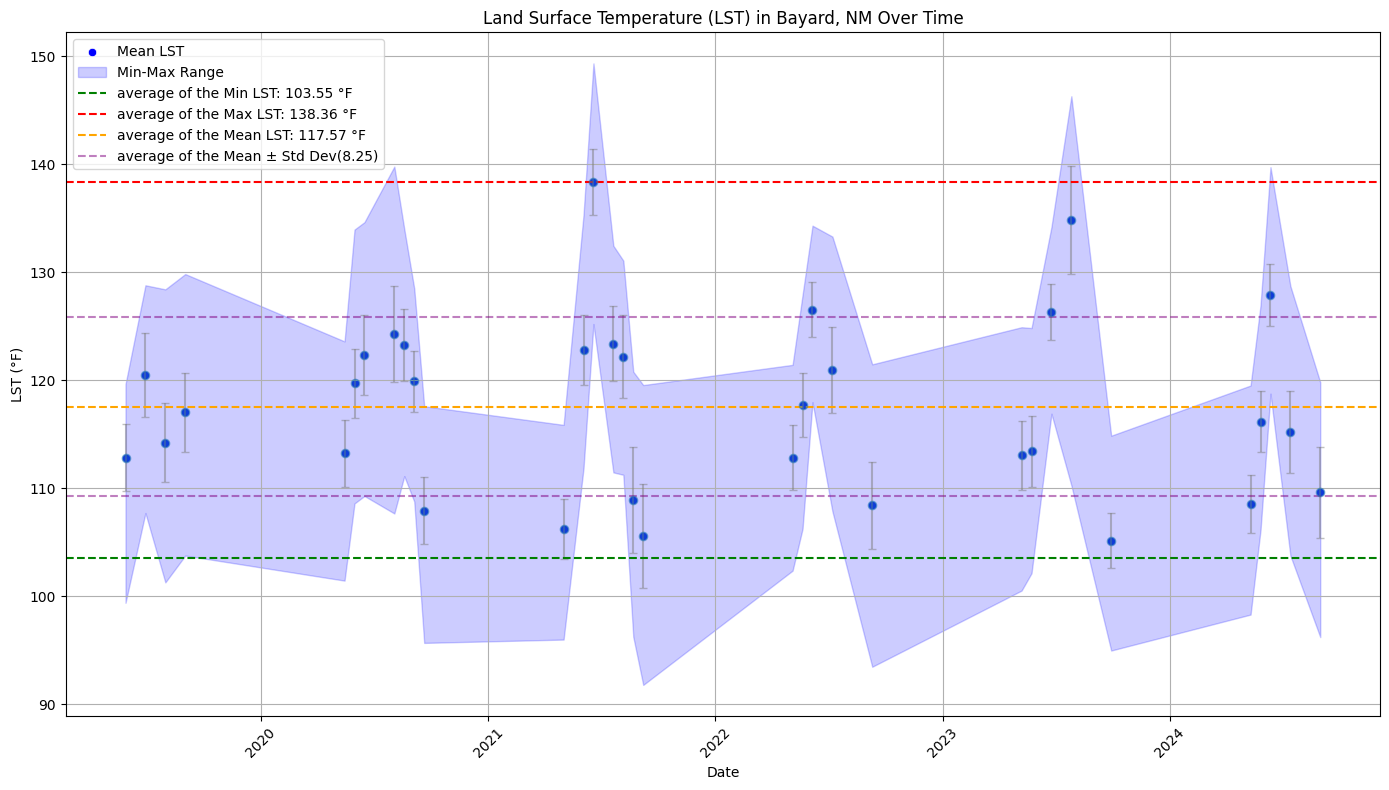

In [28]:
# Create the DataFrame
data = {
    'Date': [ee.Date(date).format("YYYY-MM-dd").getInfo() for date in dates],
    'Mean_LST': means,
    'Min_LST': mins,
    'Max_LST': maxs,
    'StdDev_LST': std_devs
}
df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])

# Overall collection statistics
overall_min = 103.55
overall_max =  138.36
overall_std_dev = 8.25
overall_mean =  117.57

# Set up the scatter plot
plt.figure(figsize=(14, 8))
sns.scatterplot(x='Date', y='Mean_LST', data=df, color='blue', label='Mean LST')

# Add error bars for standard deviation
plt.errorbar(df['Date'], df['Mean_LST'], yerr=df['StdDev_LST'], fmt='o', ecolor='gray', alpha=0.5, capsize=3)

# Add shaded area for Min-Max range
plt.fill_between(df['Date'], df['Min_LST'], df['Max_LST'], color='blue', alpha=0.2, label='Min-Max Range')

# Add overall statistics as horizontal lines
plt.axhline(overall_min, color='green', linestyle='--', label=f'average of the Min LST: {overall_min:.2f} °F')
plt.axhline(overall_max, color='red', linestyle='--', label=f'average of the Max LST: {overall_max:.2f} °F')
plt.axhline(overall_mean, color='orange', linestyle='--', label=f'average of the Mean LST: {overall_mean:.2f} °F')
plt.axhline(overall_mean + overall_std_dev, color='purple', linestyle='--', alpha=0.5, label=f'average of the Mean ± Std Dev({overall_std_dev})')
plt.axhline(overall_mean - overall_std_dev, color='purple', linestyle='--', alpha=0.5)

# Customize the plot
plt.xlabel('Date')
plt.ylabel('LST (°F)')
plt.title('Land Surface Temperature (LST) in Bayard, NM Over Time')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

In [29]:
""" # Compute the long-term baseline (mean of all images in the collection)
baseline = processed_collection.mean()

# Function to calculate the anomaly for each image
def calculate_anomaly(image):
    anomaly = image.select('LST_F').subtract(baseline.select('LST_F'))  # Subtract baseline pixel by pixel
    return image.addBands(anomaly.rename('LST_Anomaly'))  # Add anomaly as a new band

# Map the anomaly calculation across the processed collection
anomaly_collection = processed_collection.map(calculate_anomaly)

# Visualization parameters for anomalies
anomaly_vis_params = {
    'min': -20,  # Adjust based on expected range of anomalies
    'max': 20,
    'palette': ['blue', 'white', 'red'],  # Blue for cooler, red for warmer
}

# Add the mean anomaly layer to the map
Map = geemap.Map()
Map.center_object(ee_hurley, 12)

# Visualize mean anomaly across the collection
mean_anomaly = anomaly_collection.select('LST_Anomaly').mean()
Map.addLayer(mean_anomaly, anomaly_vis_params, 'Mean Temperature Anomaly')
Map.addLayer(ee_hurley, {}, 'Hurley Boundary')
Map
 """

" # Compute the long-term baseline (mean of all images in the collection)\nbaseline = processed_collection.mean()\n\n# Function to calculate the anomaly for each image\ndef calculate_anomaly(image):\n    anomaly = image.select('LST_F').subtract(baseline.select('LST_F'))  # Subtract baseline pixel by pixel\n    return image.addBands(anomaly.rename('LST_Anomaly'))  # Add anomaly as a new band\n\n# Map the anomaly calculation across the processed collection\nanomaly_collection = processed_collection.map(calculate_anomaly)\n\n# Visualization parameters for anomalies\nanomaly_vis_params = {\n    'min': -20,  # Adjust based on expected range of anomalies\n    'max': 20,\n    'palette': ['blue', 'white', 'red'],  # Blue for cooler, red for warmer\n}\n\n# Add the mean anomaly layer to the map\nMap = geemap.Map()\nMap.center_object(ee_hurley, 12)\n\n# Visualize mean anomaly across the collection\nmean_anomaly = anomaly_collection.select('LST_Anomaly').mean()\nMap.addLayer(mean_anomaly, anomaly_

In [30]:
""" # Set up export parameters
export_task = ee.batch.Export.image.toDrive(
    image=mean_anomaly.select('LST_Anomaly'),  # Select the LST band
    description='Hurley_LST_Anomaly',
    folder='lst',  # Optional: specify a folder in Google Drive
    fileNamePrefix='Hurley_LST_Anomaly',
    region=ee_hurley,
    scale=30,
    crs='EPSG:4326',  # 'EPSG:32612',  # Use UTM Zone 12N to match the Hurley vectors
    maxPixels=1e13
)

# Start the export task
export_task.start()
print("Exporting LST_Anomaly to Google Drive...") """

' # Set up export parameters\nexport_task = ee.batch.Export.image.toDrive(\n    image=mean_anomaly.select(\'LST_Anomaly\'),  # Select the LST band\n    description=\'Hurley_LST_Anomaly\',\n    folder=\'lst\',  # Optional: specify a folder in Google Drive\n    fileNamePrefix=\'Hurley_LST_Anomaly\',\n    region=ee_hurley,\n    scale=30,\n    crs=\'EPSG:4326\',  # \'EPSG:32612\',  # Use UTM Zone 12N to match the Hurley vectors\n    maxPixels=1e13\n)\n\n# Start the export task\nexport_task.start()\nprint("Exporting LST_Anomaly to Google Drive...") '

Hurley Area

In [31]:
(1874540.995237139 + 385529.09372809314)

2260070.088965232

In [32]:
2260070.088965232/4046.85642

558.4754818074895

In [33]:
558.4754818074895

558.4754818074895

SC AREA

In [34]:
2787514.188/4046.85642

688.8097571793763

Lordsburg Area

In [35]:
4747221.320008123/4046.85642

1173.0639358853564